# Energy Meter EDA — Preprocessing, Correlation, Feature Engineering & PCA

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 30)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

## 1. Data Loading & Initial Overview

In [46]:
df = pd.read_csv('total_consumption_data.csv')
df['datetime'] = pd.to_datetime(df['datetime'], unit='s')
df = df.sort_values(['meter_id', 'datetime']).reset_index(drop=True)

# Rename meter IDs to legible labels (sorted alphabetically → Meter A–F)
meter_labels = {m: f'Meter {lbl}' for m, lbl in zip(sorted(df['meter_id'].unique()), 'ABCDEF')}
df['meter_id'] = df['meter_id'].map(meter_labels)
print('Meter ID mapping:')
for orig, label in meter_labels.items():
    print(f'  {orig} → {label}')

print(f'\nShape: {df.shape}')
print(f'Date range: {df.datetime.min()} → {df.datetime.max()}')
print(f'Unique meters: {df.meter_id.nunique()}')
df.head(3)

Meter ID mapping:
  00124B0018D6F607 → Meter A
  00124B0018D6F74C → Meter B
  00124B0018D6F752 → Meter C
  00124B0018D6F755 → Meter D
  00124B0018D6FB1E → Meter E
  00124B0018D7080C → Meter F

Shape: (144256, 27)
Date range: 2019-08-27 22:00:05 → 2019-09-16 17:05:07
Unique meters: 6


,datetime,meter_id,aenergy,aenergy_ph1,aenergy_ph2,aenergy_ph3,renergy,renergy_ph1,renergy_ph2,renergy_ph3,apower,apower_ph1,apower_ph2,apower_ph3,rpower_ph1,rpower_ph2,rpower_ph3,current_ph1,current_ph2,current_ph3,pfactor,pfactor_ph1,pfactor_ph2,pfactor_ph3,voltage_ph1,voltage_ph2,voltage_ph3
0,2019-08-27 22:00:05,Meter A,4.0,19830.0,0.0,0.0,0.0,4765.0,4.0,0.0,242.0,242.0,0.0,0.0,-30.0,0.0,0.0,1.3,0.0,0.0,0.9,0.9,0.0,0.0,223.0,0.0,0.0
1,2019-08-27 22:01:05,Meter A,4.0,19834.0,0.0,0.0,0.0,4765.0,4.0,0.0,287.0,287.0,0.0,0.0,-32.0,0.0,0.0,1.4,0.0,0.0,0.9,0.9,0.0,0.0,223.0,0.0,0.0
2,2019-08-27 22:02:05,Meter A,11.0,19845.0,0.0,0.0,0.0,4765.0,4.0,0.0,1354.0,1354.0,0.0,0.0,-34.0,0.0,0.0,6.1,0.0,0.0,1.0,1.0,0.0,0.0,221.0,0.0,0.0


In [47]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
datetime,144256,2019-09-07 01:58:20.150516992,2019-08-27 22:00:05,2019-09-01 09:04:50.500000,2019-09-07 19:55:36,2019-09-12 08:53:23,2019-09-16 17:05:07,NaN
aenergy,141862.0,7.51904,0.0,0.0,3.0,9.0,393.0,11.866762
aenergy_ph1,140968.0,407827.107599,0.0,4163.75,24019.0,317474.25,2137274.0,739219.684238
aenergy_ph2,140968.0,68.282412,0.0,0.0,0.0,0.0,405.0,151.631303
aenergy_ph3,140968.0,68.556672,0.0,0.0,0.0,1.0,406.0,151.9585
renergy,140968.0,0.401176,0.0,0.0,0.0,1.0,21.0,0.741187
renergy_ph1,140968.0,70780.904659,0.0,4952.0,18762.0,119926.0,248090.0,83543.557398
renergy_ph2,140968.0,18.155177,0.0,0.0,3.0,4.0,106.0,36.394334
renergy_ph3,140968.0,1.576202,0.0,0.0,0.0,3.0,6.0,2.005942
apower,143310.0,391.135594,-3858.0,42.0,173.0,582.0,5544.0,705.694363


In [48]:
# Column groups — phase 2/3 excluded (structurally zero for single-phase meters)
# Also dropping: pfactor & apower (duplicates of pfactor_ph1 / apower_ph1 for single-phase)
ENERGY_COLS = ['aenergy', 'aenergy_ph1', 'renergy', 'renergy_ph1']
POWER_COLS  = ['apower_ph1', 'rpower_ph1']
ELEC_COLS   = ['current_ph1', 'pfactor_ph1', 'voltage_ph1']
NUM_COLS    = ENERGY_COLS + POWER_COLS + ELEC_COLS
PH1_COLS    = ['aenergy_ph1', 'renergy_ph1', 'apower_ph1', 'rpower_ph1',
               'current_ph1', 'pfactor_ph1', 'voltage_ph1']
print('Numeric columns (relevant):', len(NUM_COLS))

Numeric columns (relevant): 9


## 2. Missing Value Analysis

### 2.1 Missing Value Counts & Distribution

In [49]:
miss_count = df[NUM_COLS].isnull().sum().sort_values(ascending=False)
miss_pct   = (df[NUM_COLS].isnull().mean() * 100).sort_values(ascending=False)
miss_summary = pd.DataFrame({'Missing Count': miss_count, 'Missing %': miss_pct.round(4)})
miss_summary = miss_summary[miss_summary['Missing Count'] > 0]

print(f'Total cells      : {df[NUM_COLS].size:,}')
print(f'Total missing    : {miss_count.sum():,}')
print(f'Columns affected : {(miss_count > 0).sum()} / {len(NUM_COLS)}')
print(f'Rows with any NaN: {df[NUM_COLS].isnull().any(axis=1).sum():,}')
print()
print(miss_summary.to_string())

Total cells      : 1,298,304
Total missing    : 19,878
Columns affected : 9 / 9
Rows with any NaN: 3,829

             Missing Count  Missing %
aenergy_ph1           3288     2.2793
renergy               3288     2.2793
renergy_ph1           3288     2.2793
aenergy               2394     1.6595
rpower_ph1            1548     1.0731
pfactor_ph1           1548     1.0731
apower_ph1            1508     1.0454
current_ph1           1508     1.0454
voltage_ph1           1508     1.0454


### 2.2 Visualizations

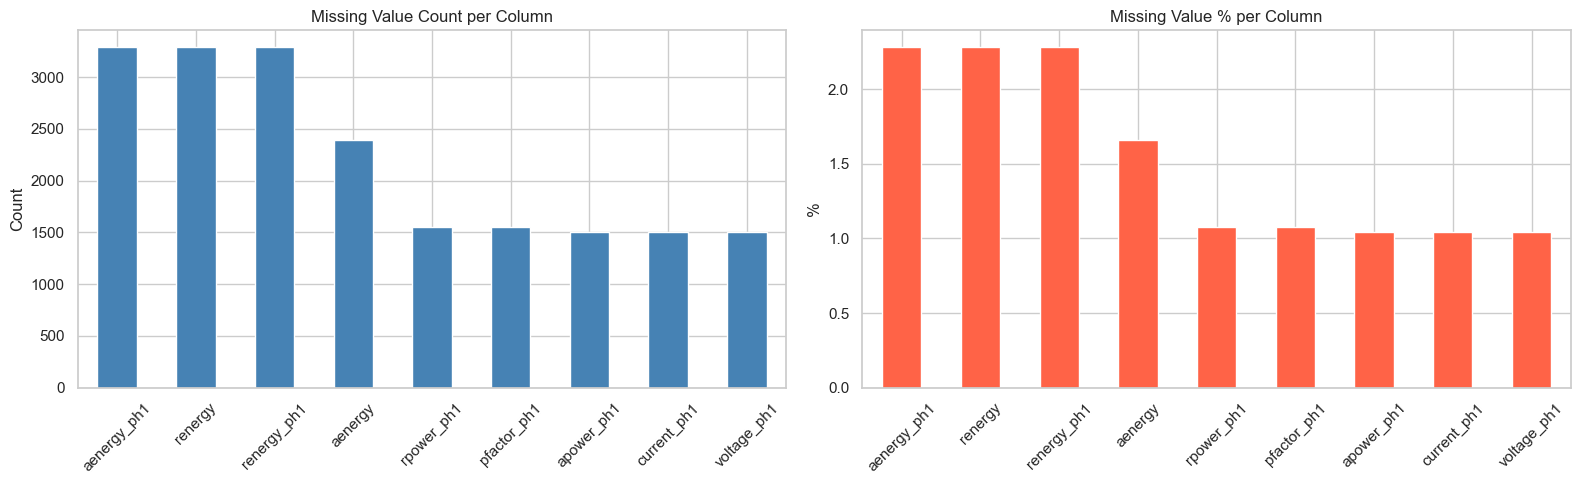

In [50]:
# --- Bar chart: missing count per column ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

miss_summary['Missing Count'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Missing Value Count per Column')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

miss_summary['Missing %'].plot(kind='bar', ax=axes[1], color='tomato', edgecolor='white')
axes[1].set_title('Missing Value % per Column')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

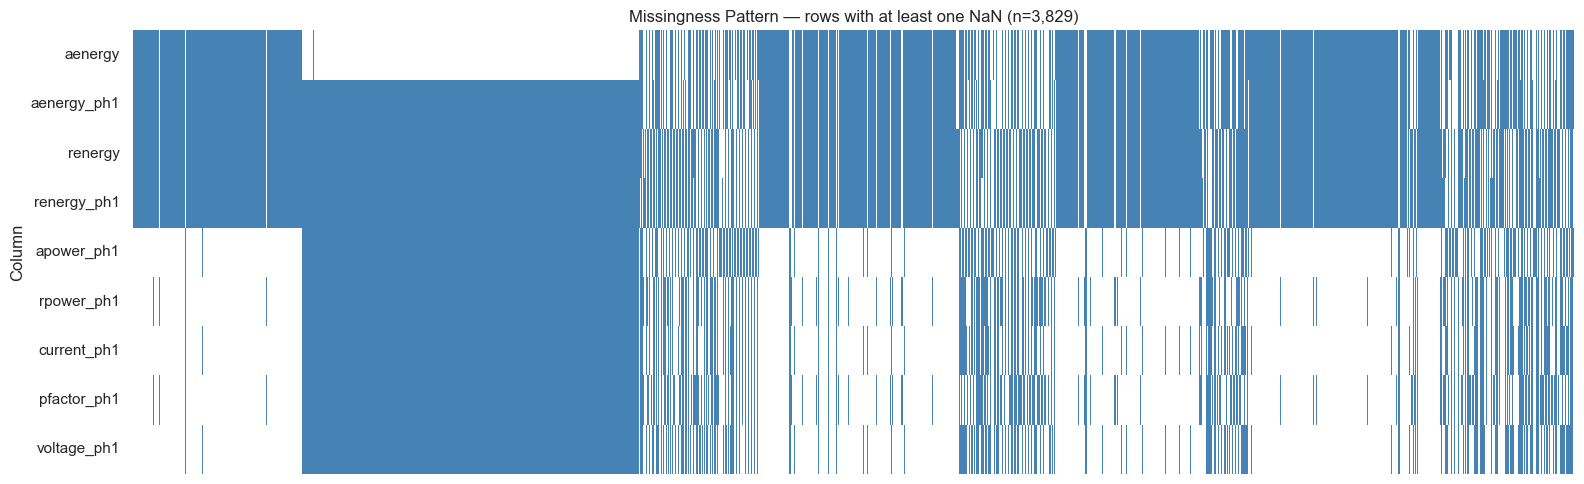

In [51]:
# --- Missingness heatmap (row sample) ---
sample_idx = df[df[NUM_COLS].isnull().any(axis=1)].index
miss_matrix = df.loc[sample_idx, NUM_COLS].isnull().astype(int)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(miss_matrix.T, cmap=['white','steelblue'], cbar=False,
            xticklabels=False, ax=ax, linewidths=0)
ax.set_title(f'Missingness Pattern — rows with at least one NaN (n={len(sample_idx):,})')
ax.set_ylabel('Column')
plt.tight_layout()
plt.show()

          Missing Rows  Total Rows  Missing %
meter_id                                     
Meter A            448       24425       1.83
Meter B           1215       24836       4.89
Meter C           1490       22855       6.52
Meter D            216       24694       0.87
Meter E             99       22548       0.44
Meter F            361       24898       1.45


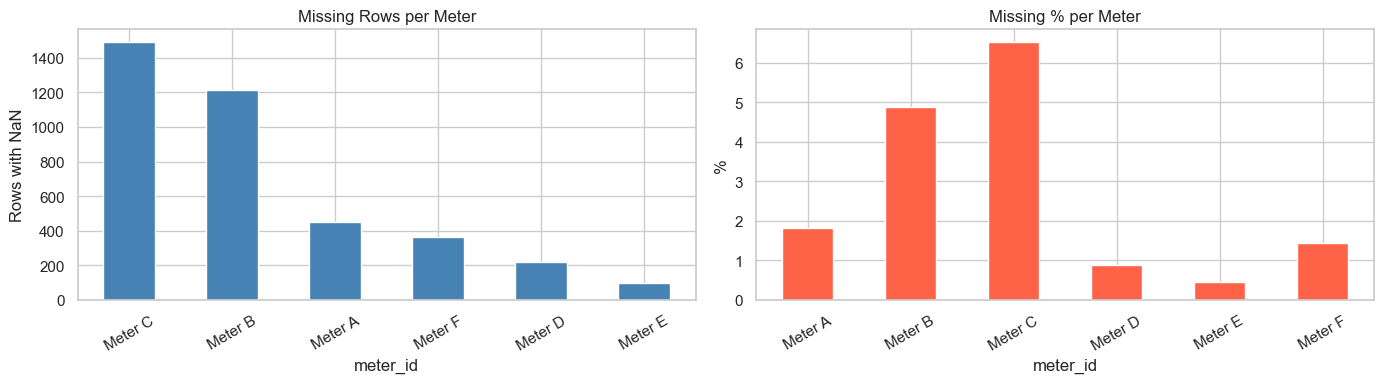

In [52]:
# --- Missing rows per meter (appliance) ---
miss_per_meter  = df.assign(has_missing=df[NUM_COLS].isnull().any(axis=1)) \
                    .groupby('meter_id')['has_missing'].sum().astype(int).sort_values(ascending=False)
total_per_meter = df.groupby('meter_id').size()
miss_pct_meter  = (miss_per_meter / total_per_meter * 100).round(2)

meter_miss_df = pd.DataFrame({'Missing Rows': miss_per_meter,
                               'Total Rows': total_per_meter,
                               'Missing %': miss_pct_meter})
print(meter_miss_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
miss_per_meter.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Missing Rows per Meter')
axes[0].set_ylabel('Rows with NaN')
axes[0].tick_params(axis='x', rotation=30)

miss_pct_meter.plot(kind='bar', ax=axes[1], color='tomato', edgecolor='white')
axes[1].set_title('Missing % per Meter')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

### 2.3 Little's MCAR Test & MAR/MNAR Classification

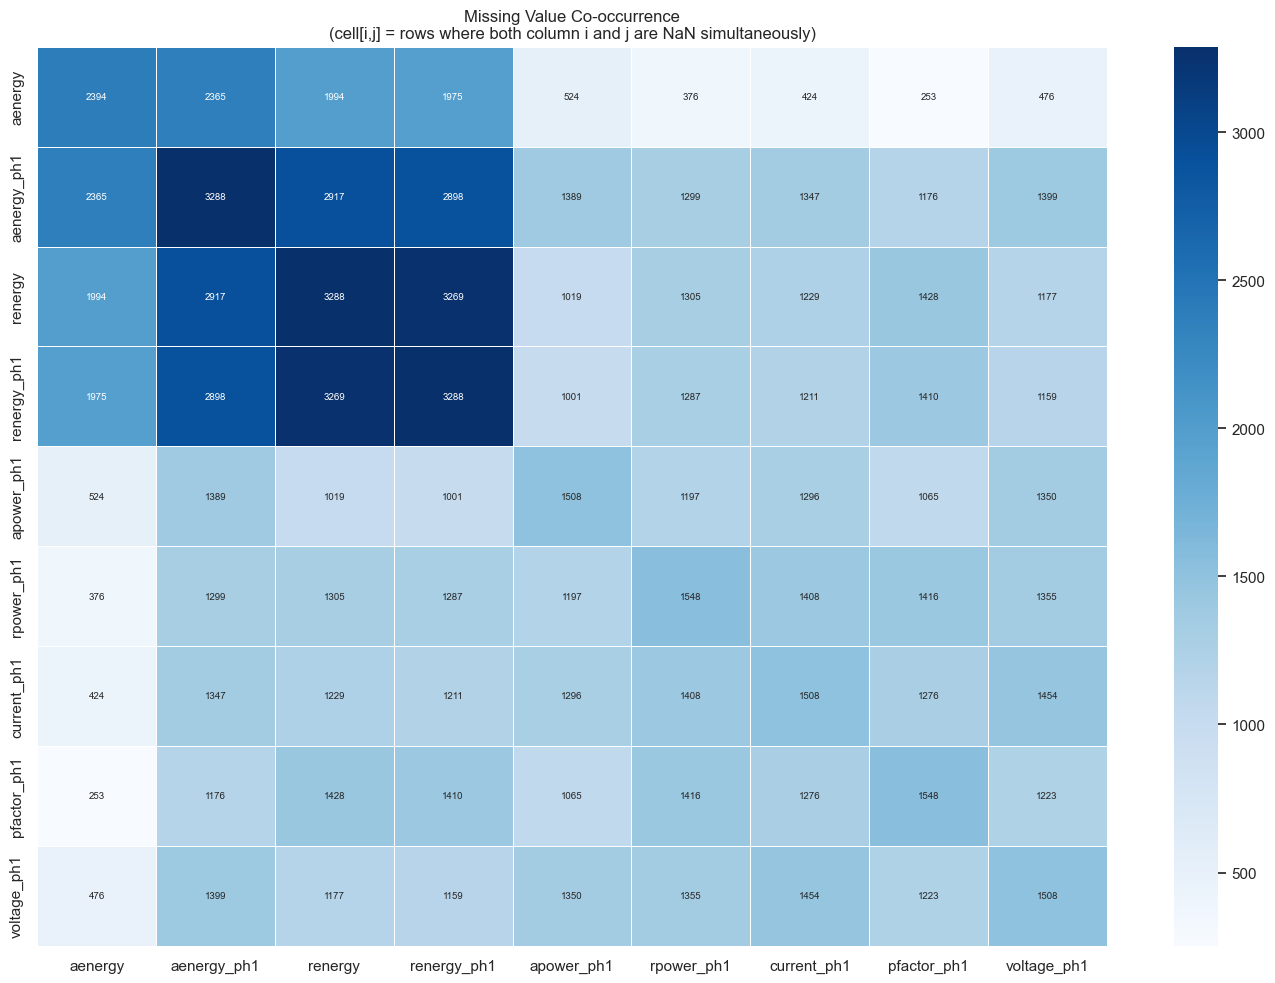

In [53]:
# --- Missing co-occurrence: which columns tend to be missing together ---
miss_ind = df[NUM_COLS].isnull().astype(int)
co_occur  = miss_ind.T.dot(miss_ind)

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(co_occur, annot=True, fmt='d', cmap='Blues',
            linewidths=0.4, ax=ax, annot_kws={'size': 7})
ax.set_title('Missing Value Co-occurrence\n(cell[i,j] = rows where both column i and j are NaN simultaneously)')
plt.tight_layout()
plt.show()

In [54]:
def littles_mcar_test(df_num):
    """
    Little's MCAR test (1988).
    H0: data is Missing Completely At Random.
    Returns chi2 statistic, p-value, degrees of freedom.
    """
    data  = df_num.copy().reset_index(drop=True)
    n, p  = data.shape
    cols  = data.columns.tolist()

    # Grand means and covariance (listwise deletion for estimates)
    mu_hat  = data.mean()
    cov_hat = data.cov()

    # Identify unique missing patterns
    miss_pat = data.isnull()
    patterns  = miss_pat.drop_duplicates()

    d2   = 0.0
    dof  = 0

    for _, pat in patterns.iterrows():
        obs_cols = pat[~pat].index.tolist()   # columns observed in this pattern
        if not obs_cols:
            continue
        # Rows matching this pattern
        mask = (miss_pat == pat).all(axis=1)
        n_j  = mask.sum()
        if n_j == 0:
            continue

        ybar_j = data.loc[mask, obs_cols].mean()
        mu_j   = mu_hat[obs_cols]
        diff   = (ybar_j - mu_j).values

        cov_j  = cov_hat.loc[obs_cols, obs_cols].values
        try:
            cov_inv = np.linalg.pinv(cov_j)
            d2 += n_j * float(diff @ cov_inv @ diff)
            dof += len(obs_cols)
        except Exception:
            pass

    dof -= p   # subtract estimated grand-mean parameters
    dof  = max(dof, 1)
    p_val = 1 - stats.chi2.cdf(d2, df=dof)

    return d2, p_val, dof

# Run only on numeric cols that have missingness
miss_cols_only = [c for c in NUM_COLS if df[c].isnull().any()]
chi2_stat, p_val, dof = littles_mcar_test(df[miss_cols_only])

print('='*50)
print("Little's MCAR Test")
print('='*50)
print(f'Chi-square statistic : {chi2_stat:.4f}')
print(f'Degrees of freedom   : {dof}')
print(f'p-value              : {p_val:.6f}')
print()
if p_val < 0.05:
    print('Result: REJECT H0 → Data is NOT MCAR (likely MAR or MNAR)')
else:
    print('Result: FAIL TO REJECT H0 → Data is consistent with MCAR')

Little's MCAR Test
Chi-square statistic : 1364.9578
Degrees of freedom   : 116
p-value              : 0.000000

Result: REJECT H0 → Data is NOT MCAR (likely MAR or MNAR)


In [55]:
# t-test based MAR/MNAR classification per missing column
# For each missing column, test if observed values of OTHER columns differ
# significantly between rows where this column is missing vs present.
# Significant difference → MAR (missingness depends on observed data).
# No significant difference → consistent with MCAR (or MNAR if value-driven).

alpha = 0.05
results = []

for col in miss_cols_only:
    miss_mask   = df[col].isnull()
    sig_refs    = []
    for ref in miss_cols_only:
        if ref == col:
            continue
        grp_miss    = df.loc[ miss_mask, ref].dropna()
        grp_present = df.loc[~miss_mask, ref].dropna()
        if len(grp_miss) < 5:
            continue
        _, p = stats.ttest_ind(grp_miss, grp_present, equal_var=False)
        if p < alpha:
            sig_refs.append(ref)
    if sig_refs:
        mechanism = 'MAR'
        note      = f'depends on: {sig_refs[:3]}{"..." if len(sig_refs)>3 else ""}'
    else:
        mechanism = 'MCAR/MNAR'
        note      = 'no observed-data dependency detected'
    results.append({'Column': col, 'Missing': int(miss_mask.sum()),
                    'Mechanism': mechanism, 'Note': note})

mech_df = pd.DataFrame(results)
print(mech_df.to_string(index=False))

     Column  Missing Mechanism                                                        Note
    aenergy     2394       MAR depends on: ['aenergy_ph1', 'renergy_ph1', 'apower_ph1']...
aenergy_ph1     3288       MAR     depends on: ['aenergy', 'renergy_ph1', 'apower_ph1']...
    renergy     3288       MAR    depends on: ['aenergy', 'aenergy_ph1', 'renergy_ph1']...
renergy_ph1     3288       MAR        depends on: ['aenergy', 'aenergy_ph1', 'renergy']...
 apower_ph1     1508       MAR    depends on: ['aenergy', 'aenergy_ph1', 'renergy_ph1']...
 rpower_ph1     1548       MAR        depends on: ['aenergy', 'aenergy_ph1', 'renergy']...
current_ph1     1508       MAR        depends on: ['aenergy', 'aenergy_ph1', 'renergy']...
pfactor_ph1     1548       MAR    depends on: ['aenergy', 'aenergy_ph1', 'renergy_ph1']...
voltage_ph1     1508       MAR        depends on: ['aenergy', 'aenergy_ph1', 'apower_ph1']


### 2.4 Imputation Techniques

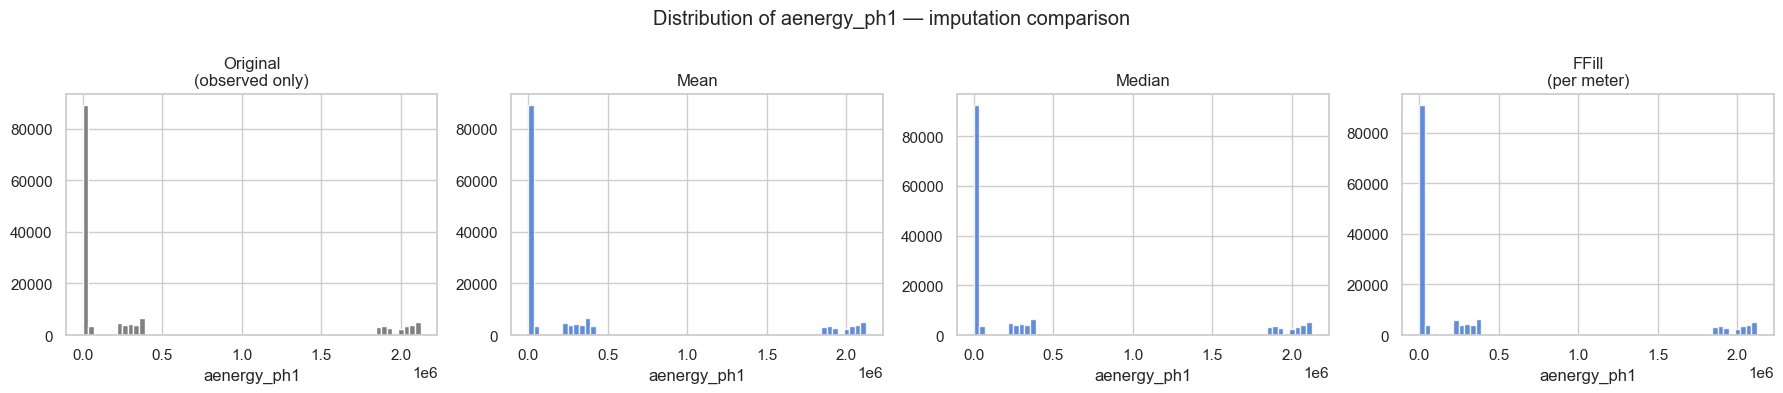

Method                        Mean           Std           Min           Max
Original                 407827.11     739219.68          0.00    2137274.00
Mean                     407827.11     730746.62          0.00    2137274.00
Median                   399079.04     732988.19          0.00    2137274.00
FFill (per meter)        403405.97     734831.70          0.00    2137274.00


In [56]:
work_cols = [c for c in NUM_COLS if df[c].isnull().any()]
X_miss    = df[work_cols].copy()

# Since all columns are MAR and data is time-series sensor readings sorted by
# meter + time, forward-fill per meter is the most appropriate imputation:
# a missing reading is best estimated by the meter's last known value.
# KNN and MICE are excluded — infeasible at 144K rows × 25 columns.

# 1. Mean imputation (global)
mean_arr = SimpleImputer(strategy='mean').fit_transform(X_miss)

# 2. Median imputation (global)
med_arr  = SimpleImputer(strategy='median').fit_transform(X_miss)

# 3. Forward-fill per meter, back-fill for any leading NaNs (time-series aware)
ffill_df = df[['meter_id'] + work_cols].copy()
ffill_df[work_cols] = (
    ffill_df.groupby('meter_id')[work_cols]
            .transform(lambda x: x.ffill().bfill())
)
ffill_arr = ffill_df[work_cols].values

methods = {
    'Mean'   : mean_arr,
    'Median' : med_arr,
    'FFill\n(per meter)': ffill_arr,
}

# Distribution comparison on a representative column
ref_col  = 'aenergy_ph1'
ref_idx  = work_cols.index(ref_col)
orig     = X_miss[ref_col].dropna()
lo, hi   = orig.quantile(0.01), orig.quantile(0.99)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].hist(orig.clip(lo, hi), bins=60, color='gray', edgecolor='white')
axes[0].set_title('Original\n(observed only)')

for ax, (name, arr) in zip(axes[1:], methods.items()):
    ax.hist(pd.Series(arr[:, ref_idx]).clip(lo, hi), bins=60, edgecolor='white', alpha=0.85)
    ax.set_title(f'{name}')

for ax in axes:
    ax.set_xlabel(ref_col)
plt.suptitle(f'Distribution of {ref_col} — imputation comparison')
plt.tight_layout()
plt.show()

# Summary stats
print(f'{"Method":20s}  {"Mean":>12s}  {"Std":>12s}  {"Min":>12s}  {"Max":>12s}')
print(f'{"Original":20s}  {orig.mean():>12.2f}  {orig.std():>12.2f}  {orig.min():>12.2f}  {orig.max():>12.2f}')
for name, arr in methods.items():
    s = pd.Series(arr[:, ref_idx])
    print(f'{name.replace(chr(10)," "):20s}  {s.mean():>12.2f}  {s.std():>12.2f}  {s.min():>12.2f}  {s.max():>12.2f}')

In [57]:
# Use forward-fill per meter as the canonical imputed dataset.
# Best choice for MAR time-series data: preserves local temporal patterns,
# avoids mean-shift bias from global imputers, and runs in <1 second.
df_clean = df.copy()
df_clean[work_cols] = (
    df_clean.groupby('meter_id')[work_cols]
            .transform(lambda x: x.ffill().bfill())
)
print('Missing values remaining:', df_clean[work_cols].isnull().sum().sum())

Missing values remaining: 0


In [58]:
# Drop zero-value phase 2/3 columns and redundant aggregate columns
ZERO_COLS = [
    'aenergy_ph2', 'aenergy_ph3',
    'renergy_ph2', 'renergy_ph3',
    'apower', 'apower_ph2', 'apower_ph3',
    'rpower_ph2', 'rpower_ph3',
    'current_ph2', 'current_ph3',
    'pfactor', 'pfactor_ph2', 'pfactor_ph3',
    'voltage_ph2', 'voltage_ph3',
]
df_clean = df_clean.drop(columns=ZERO_COLS)
print(f'Dropped {len(ZERO_COLS)} zero/redundant columns.')
print(f'df_clean shape: {df_clean.shape}')
print(f'Remaining numeric columns: {[c for c in df_clean.columns if c not in ["datetime", "meter_id"]]}')

Dropped 16 zero/redundant columns.
df_clean shape: (144256, 11)
Remaining numeric columns: ['aenergy', 'aenergy_ph1', 'renergy', 'renergy_ph1', 'apower_ph1', 'rpower_ph1', 'current_ph1', 'pfactor_ph1', 'voltage_ph1']


## 3. Outlier Handling via Discretization

In [59]:
# IQR-based outlier detection
def iqr_outlier_pct(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return ((series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)).mean() * 100

outlier_pcts = {c: iqr_outlier_pct(df_clean[c].dropna()) for c in PH1_COLS}
out_series   = pd.Series(outlier_pcts).sort_values(ascending=False)
print('Outlier % per column:')
print(out_series.round(2).to_string())

Outlier % per column:
pfactor_ph1    17.25
aenergy_ph1    17.12
apower_ph1     10.50
voltage_ph1     7.22
current_ph1     4.51
rpower_ph1      0.40
renergy_ph1     0.00


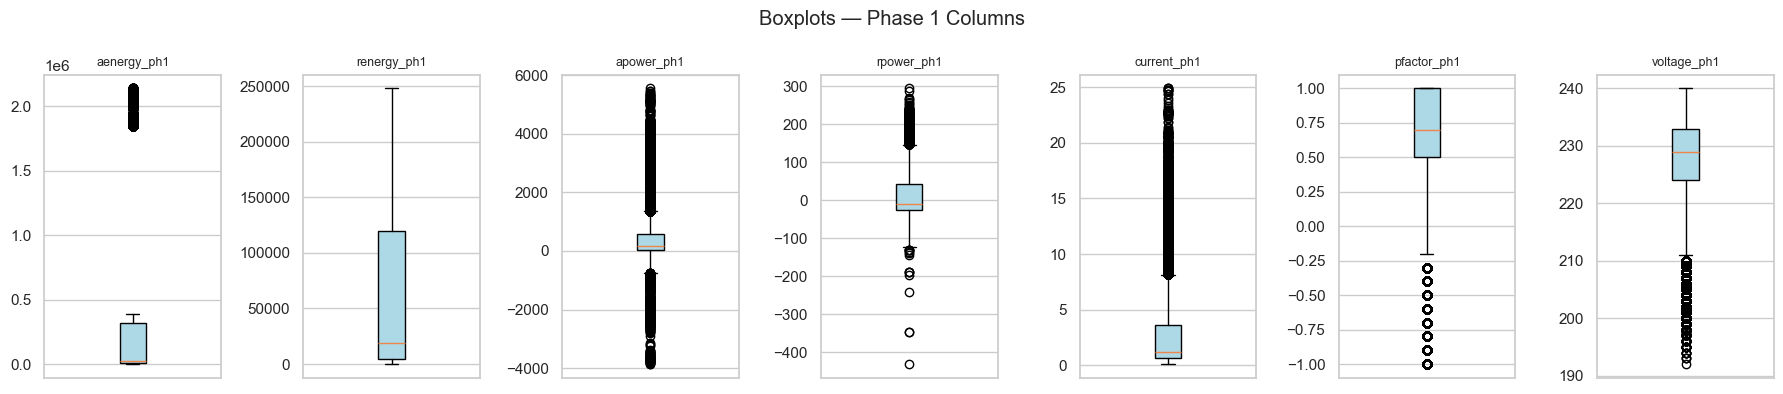

In [60]:
fig, axes = plt.subplots(1, len(PH1_COLS), figsize=(18, 4))
for ax, col in zip(axes, PH1_COLS):
    ax.boxplot(df_clean[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='lightblue'))
    ax.set_title(col, fontsize=9)
    ax.set_xticks([])
plt.suptitle('Boxplots — Phase 1 Columns')
plt.tight_layout()
plt.show()

In [61]:
# Equal-frequency (quantile) binning to cap influence of extreme outliers
# Justification: energy/power data is right-skewed; quantile bins create uniform
# frequency bands and naturally absorb outliers into the top/bottom bins.

def qcut_discretize(series, q=10):
    return pd.qcut(series, q=q, labels=False, duplicates='drop')

disc_cols = ['aenergy_ph1', 'apower_ph1', 'current_ph1']
df_disc   = df_clean.copy()
for col in disc_cols:
    df_disc[f'{col}_bin'] = qcut_discretize(df_disc[col])

# Equal-width binning for voltage (bounded variable, less skewed)
df_disc['voltage_ph1_bin'] = pd.cut(df_disc['voltage_ph1'], bins=5, labels=False)

print(df_disc[[c for c in df_disc.columns if '_bin' in c]].describe().T[['count','mean','min','max']])

                    count      mean  min  max
aenergy_ph1_bin  144256.0  3.599961  0.0  8.0
apower_ph1_bin   144256.0  4.491730  0.0  9.0
current_ph1_bin  144256.0  4.376553  0.0  9.0
voltage_ph1_bin  144256.0  3.113735  0.0  4.0


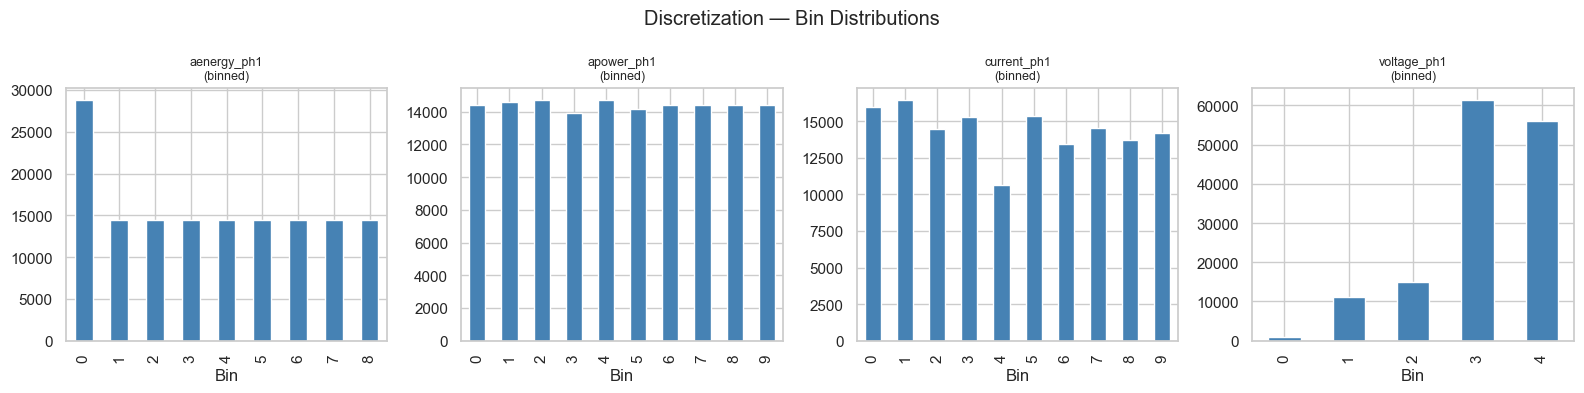

In [62]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, disc_cols + ['voltage_ph1']):
    bin_col = f'{col}_bin'
    df_disc[bin_col].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'{col}\n(binned)', fontsize=9)
    ax.set_xlabel('Bin')
plt.suptitle('Discretization — Bin Distributions')
plt.tight_layout()
plt.show()

## 4. Scaling & Normalization

In [63]:
# Use phase-1 numeric columns for scaling demos
scale_cols = PH1_COLS
X_scale    = df_clean[scale_cols].dropna().copy()

# Z-score (StandardScaler) — Gaussian-distributed features; zero-mean, unit-variance
X_std   = pd.DataFrame(StandardScaler().fit_transform(X_scale),  columns=scale_cols)

# Min-Max — bounded [0,1]; useful for neural nets / distance metrics
X_mm    = pd.DataFrame(MinMaxScaler().fit_transform(X_scale),     columns=scale_cols)

# Robust (median/IQR) — best for columns with confirmed heavy outliers
X_rob   = pd.DataFrame(RobustScaler().fit_transform(X_scale),     columns=scale_cols)

# Decision:
#   voltage_ph1  → StandardScaler (near-Gaussian, few outliers)
#   apower_ph1   → RobustScaler   (heavy right skew)
#   current_ph1  → RobustScaler   (heavy right skew)
#   aenergy_ph1  → RobustScaler   (cumulative counter, extreme range)
#   pfactor_ph1  → MinMaxScaler   (bounded [-1,1] semantically)
#   renergy_ph1  → RobustScaler
#   rpower_ph1   → RobustScaler

scaler_map = {
    'aenergy_ph1': RobustScaler(),
    'renergy_ph1': RobustScaler(),
    'apower_ph1':  RobustScaler(),
    'rpower_ph1':  RobustScaler(),
    'current_ph1': RobustScaler(),
    'pfactor_ph1': MinMaxScaler(),
    'voltage_ph1': StandardScaler(),
}

X_final = X_scale.copy()
for col, scaler in scaler_map.items():
    X_final[[col]] = scaler.fit_transform(X_scale[[col]])

print('Scaled stats (final):')
X_final.describe().T[['mean','std','min','max']].round(3)

Scaled stats (final):


,mean,std,min,max
aenergy_ph1,1.216,2.357,-0.078,6.778
renergy_ph1,0.451,0.724,-0.163,1.993
apower_ph1,0.414,1.346,-7.689,10.245
rpower_ph1,0.277,0.714,-6.087,4.420
current_ph1,0.407,0.929,-0.367,7.900
pfactor_ph1,0.759,0.309,0.000,1.000
voltage_ph1,-0.000,1.000,-4.174,1.538


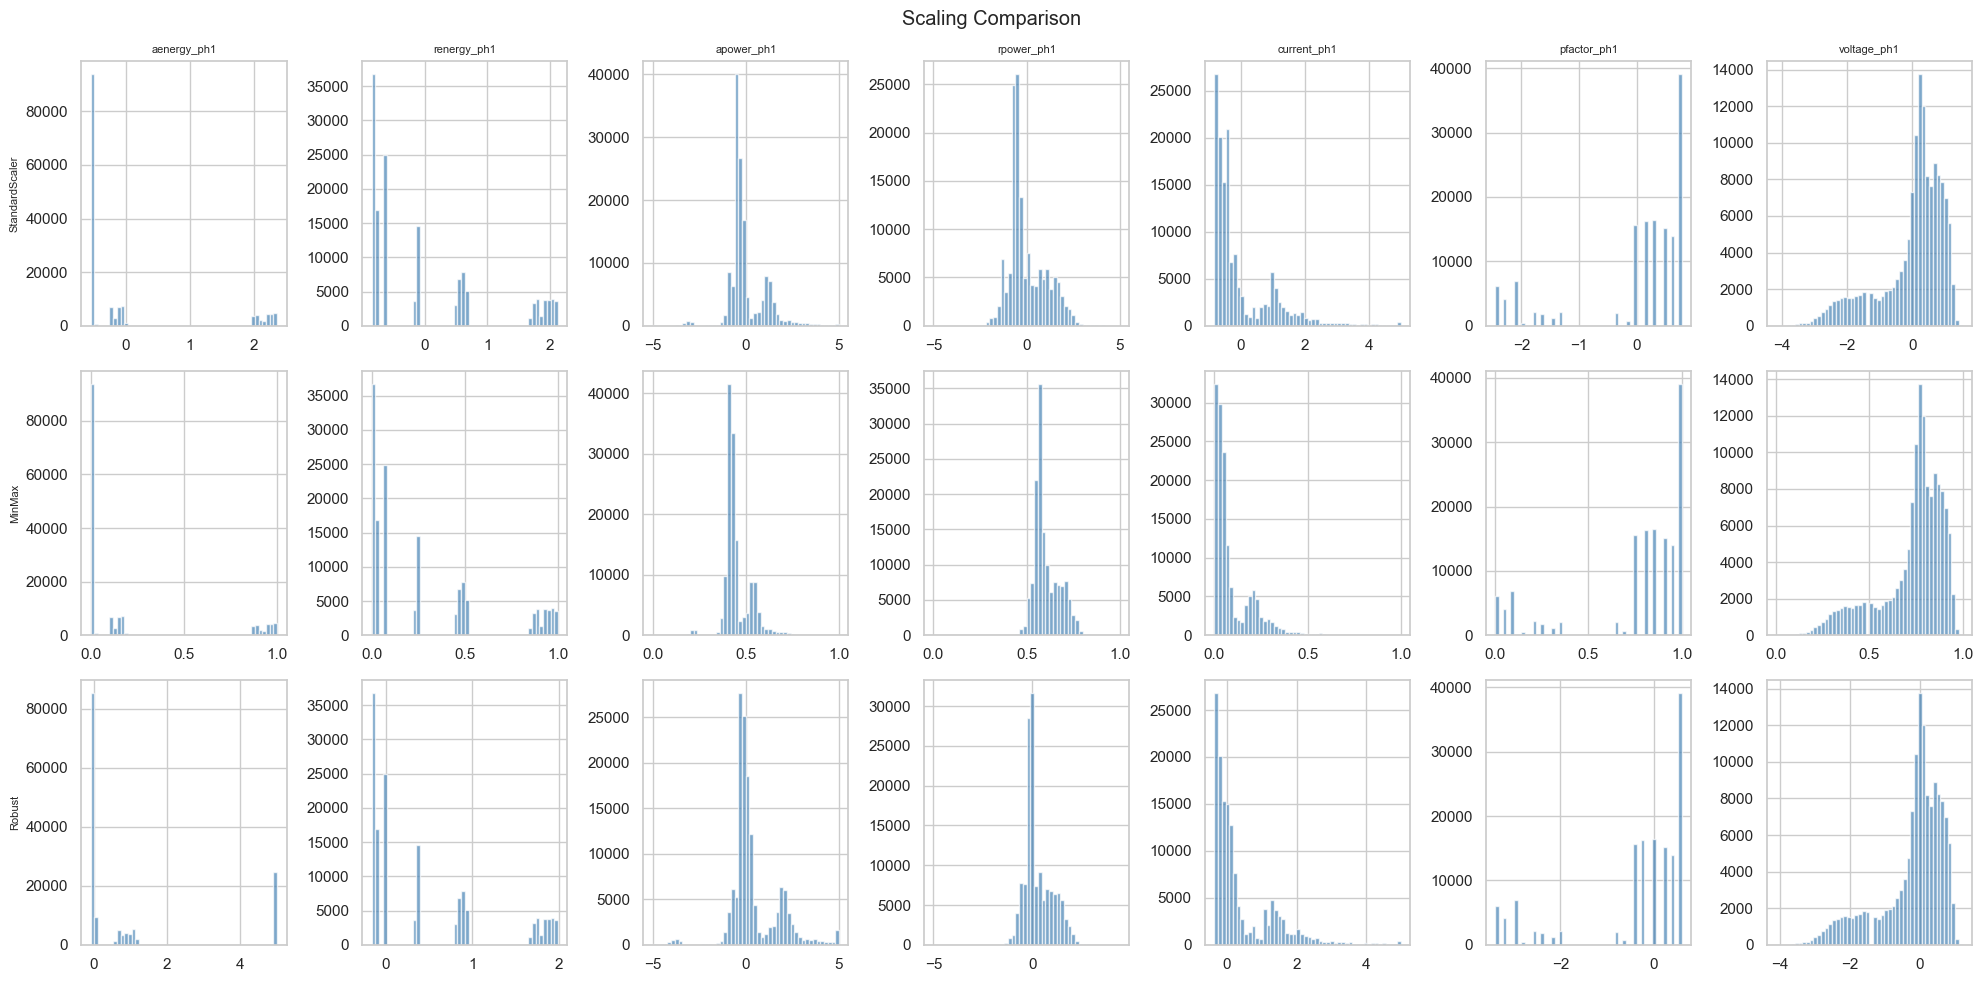

In [64]:
fig, axes = plt.subplots(3, len(scale_cols), figsize=(20, 10))
for j, col in enumerate(scale_cols):
    for i, (label, X) in enumerate(zip(['StandardScaler','MinMax','Robust'],
                                        [X_std, X_mm, X_rob])):
        axes[i, j].hist(X[col].clip(-5,5), bins=50, color='steelblue', alpha=0.7)
        if j == 0: axes[i, j].set_ylabel(label, fontsize=8)
        if i == 0: axes[i, j].set_title(col, fontsize=8)
plt.suptitle('Scaling Comparison')
plt.tight_layout()
plt.show()

## 5. Correlation Analysis

### 5.1 Pearson & Spearman

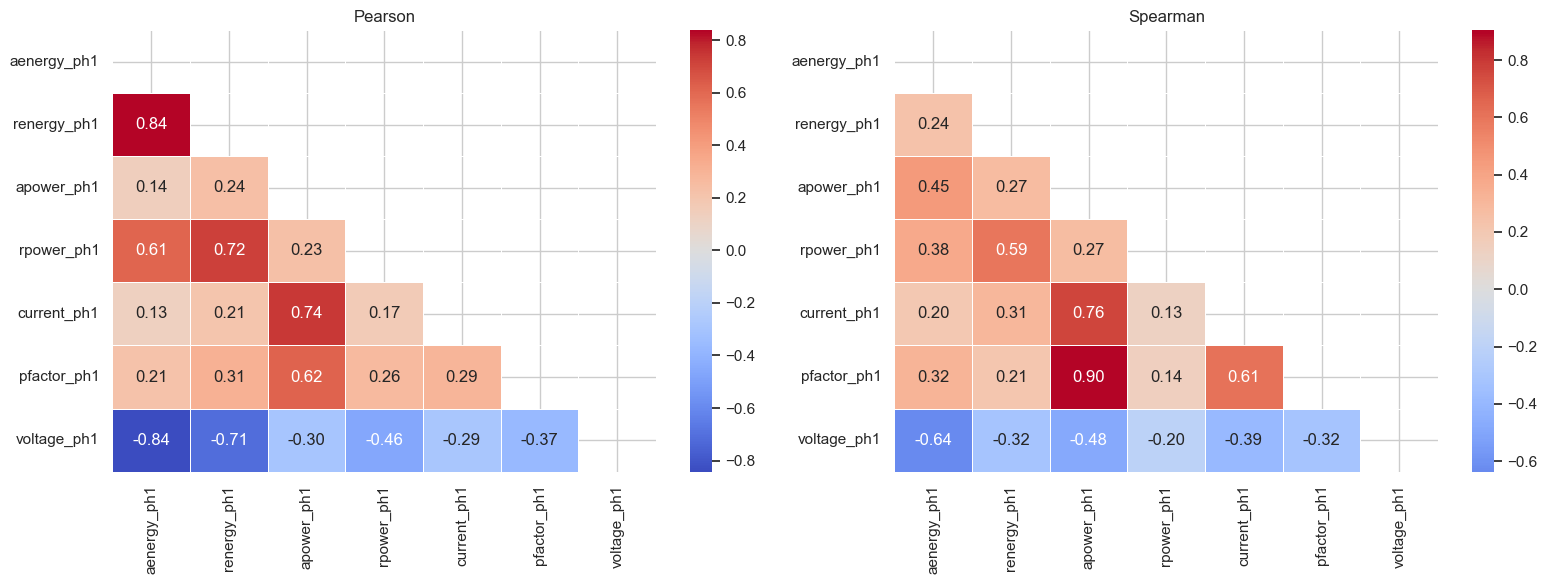

In [65]:
corr_df = df_clean[PH1_COLS].dropna()

pearson  = corr_df.corr(method='pearson')
spearman = corr_df.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
mask = np.triu(np.ones_like(pearson, dtype=bool))
for ax, mat, title in zip(axes, [pearson, spearman], ['Pearson', 'Spearman']):
    sns.heatmap(mat, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                mask=mask, ax=ax, linewidths=0.5)
    ax.set_title(title)
plt.tight_layout()
plt.show()

### 5.2 Covariance Matrix

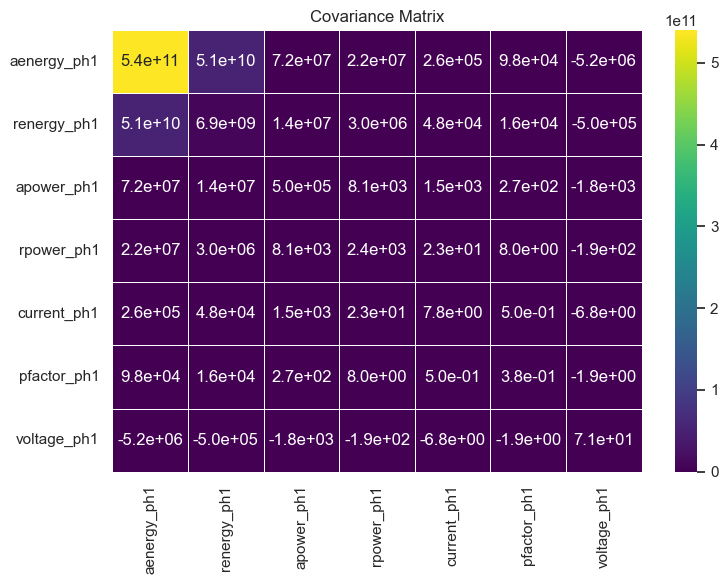

In [66]:
cov_mat = corr_df.cov()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cov_mat, annot=True, fmt='.1e', cmap='viridis', ax=ax, linewidths=0.5)
ax.set_title('Covariance Matrix')
plt.tight_layout()
plt.show()

### 5.3 Partial Correlation

In [67]:
def partial_corr(df, x, y, covar):
    """Partial correlation of x and y controlling for covar, with p-value."""
    sub = df[[x, y, covar]].dropna()
    n   = len(sub)
    # Residuals of x ~ covar and y ~ covar
    def residuals(target, predictor):
        b = np.cov(sub[predictor], sub[target])[0,1] / np.var(sub[predictor])
        a = sub[target].mean() - b * sub[predictor].mean()
        return sub[target] - (a + b * sub[predictor])

    rx = residuals(x, covar)
    ry = residuals(y, covar)
    r, _ = stats.pearsonr(rx, ry)
    # t-statistic with n-3 df (one covariate removed)
    t   = r * np.sqrt((n - 3) / (1 - r**2 + 1e-12))
    p   = 2 * stats.t.sf(abs(t), df=n - 3)
    ci  = np.tanh(np.arctanh(r) + np.array([-1, 1]) * 1.96 / np.sqrt(n - 3))
    return {'r': round(r, 4), 'CI95%': ci.round(4).tolist(), 'p-val': round(p, 6), 'n': n}

pc1 = partial_corr(corr_df, 'apower_ph1', 'aenergy_ph1', 'current_ph1')
print('Partial corr (apower_ph1 ~ aenergy_ph1 | current_ph1):')
print(pd.DataFrame([pc1]).to_string(index=False))

print()
pc2 = partial_corr(corr_df, 'voltage_ph1', 'pfactor_ph1', 'apower_ph1')
print('Partial corr (voltage_ph1 ~ pfactor_ph1 | apower_ph1):')
print(pd.DataFrame([pc2]).to_string(index=False))

Partial corr (apower_ph1 ~ aenergy_ph1 | current_ph1):
     r           CI95%  p-val      n
0.0671 [0.062, 0.0722]    0.0 144256

Partial corr (voltage_ph1 ~ pfactor_ph1 | apower_ph1):
     r              CI95%  p-val      n
-0.244 [-0.2488, -0.2391]    0.0 144256


### 5.4 Multiple Correlation (R²) — apower_ph1 as target

In [68]:
target   = 'apower_ph1'
features = [c for c in PH1_COLS if c != target]
X_mc = corr_df[features]
y_mc = corr_df[target]

reg  = LinearRegression().fit(X_mc, y_mc)
R2   = reg.score(X_mc, y_mc)
R    = np.sqrt(R2)

print(f'Multiple Correlation R  = {R:.4f}')
print(f'R²                      = {R2:.4f}')
coef_df = pd.Series(reg.coef_, index=features).sort_values(key=abs, ascending=False)
print('\nStandardized coefficients (proxy):')
print(coef_df.round(4).to_string())

Multiple Correlation R  = 0.8554
R²                      = 0.7317

Standardized coefficients (proxy):
pfactor_ph1    512.9497
current_ph1    158.3731
voltage_ph1      4.2399
rpower_ph1       0.8930
renergy_ph1     -0.0004
aenergy_ph1      0.0000


## 6. Feature Engineering

In [69]:
df_fe = df_clean.copy()

# 1. Apparent Power (VA) = V × I — measures total power delivered
df_fe['apparent_power_ph1'] = df_fe['voltage_ph1'] * df_fe['current_ph1']

# 2. Power Factor Angle (radians) — deeper look at reactive behaviour
pf_clipped = df_fe['pfactor_ph1'].clip(-1, 1)
df_fe['pf_angle_ph1'] = np.arccos(pf_clipped)

# 3. Energy Intensity = aenergy_ph1 / apparent_power_ph1 — efficiency ratio
df_fe['energy_intensity'] = df_fe['aenergy_ph1'] / (df_fe['apparent_power_ph1'] + 1e-6)

# 4. Reactive-to-Active Power Ratio — measures load type (capacitive vs inductive)
df_fe['Q_P_ratio'] = df_fe['rpower_ph1'] / (df_fe['apower_ph1'].abs() + 1e-6)

# 5. Temporal features from datetime
df_fe['hour']       = df_fe['datetime'].dt.hour
df_fe['dayofweek']  = df_fe['datetime'].dt.dayofweek
df_fe['is_weekend'] = (df_fe['dayofweek'] >= 5).astype(int)
df_fe['is_peak']    = df_fe['hour'].between(8, 20).astype(int)  # business hours

# 6. Rolling mean apower (per meter, 3-sample window) — smoothed load trend
df_fe['apower_roll3'] = (
    df_fe.groupby('meter_id')['apower_ph1']
         .transform(lambda x: x.rolling(3, min_periods=1).mean())
)

new_feats = ['apparent_power_ph1', 'pf_angle_ph1', 'energy_intensity',
             'Q_P_ratio', 'hour', 'dayofweek', 'is_weekend', 'is_peak', 'apower_roll3']
print('New features added:', new_feats)
df_fe[new_feats].describe().T[['mean', 'std', 'min', 'max']].round(3)

New features added: ['apparent_power_ph1', 'pf_angle_ph1', 'energy_intensity', 'Q_P_ratio', 'hour', 'dayofweek', 'is_weekend', 'is_peak', 'apower_roll3']


,mean,std,min,max
apparent_power_ph1,542.962,617.053,23.200,5555.200
pf_angle_ph1,0.884,0.868,0.000,3.142
energy_intensity,1355.622,3428.882,0.000,51499.402
Q_P_ratio,-0.006,0.296,-4.226,4.303
hour,11.161,6.886,0.000,23.000
dayofweek,3.227,2.062,0.000,6.000
is_weekend,0.342,0.474,0.000,1.000
is_peak,0.531,0.499,0.000,1.000
apower_roll3,389.947,680.061,-3800.333,5385.333


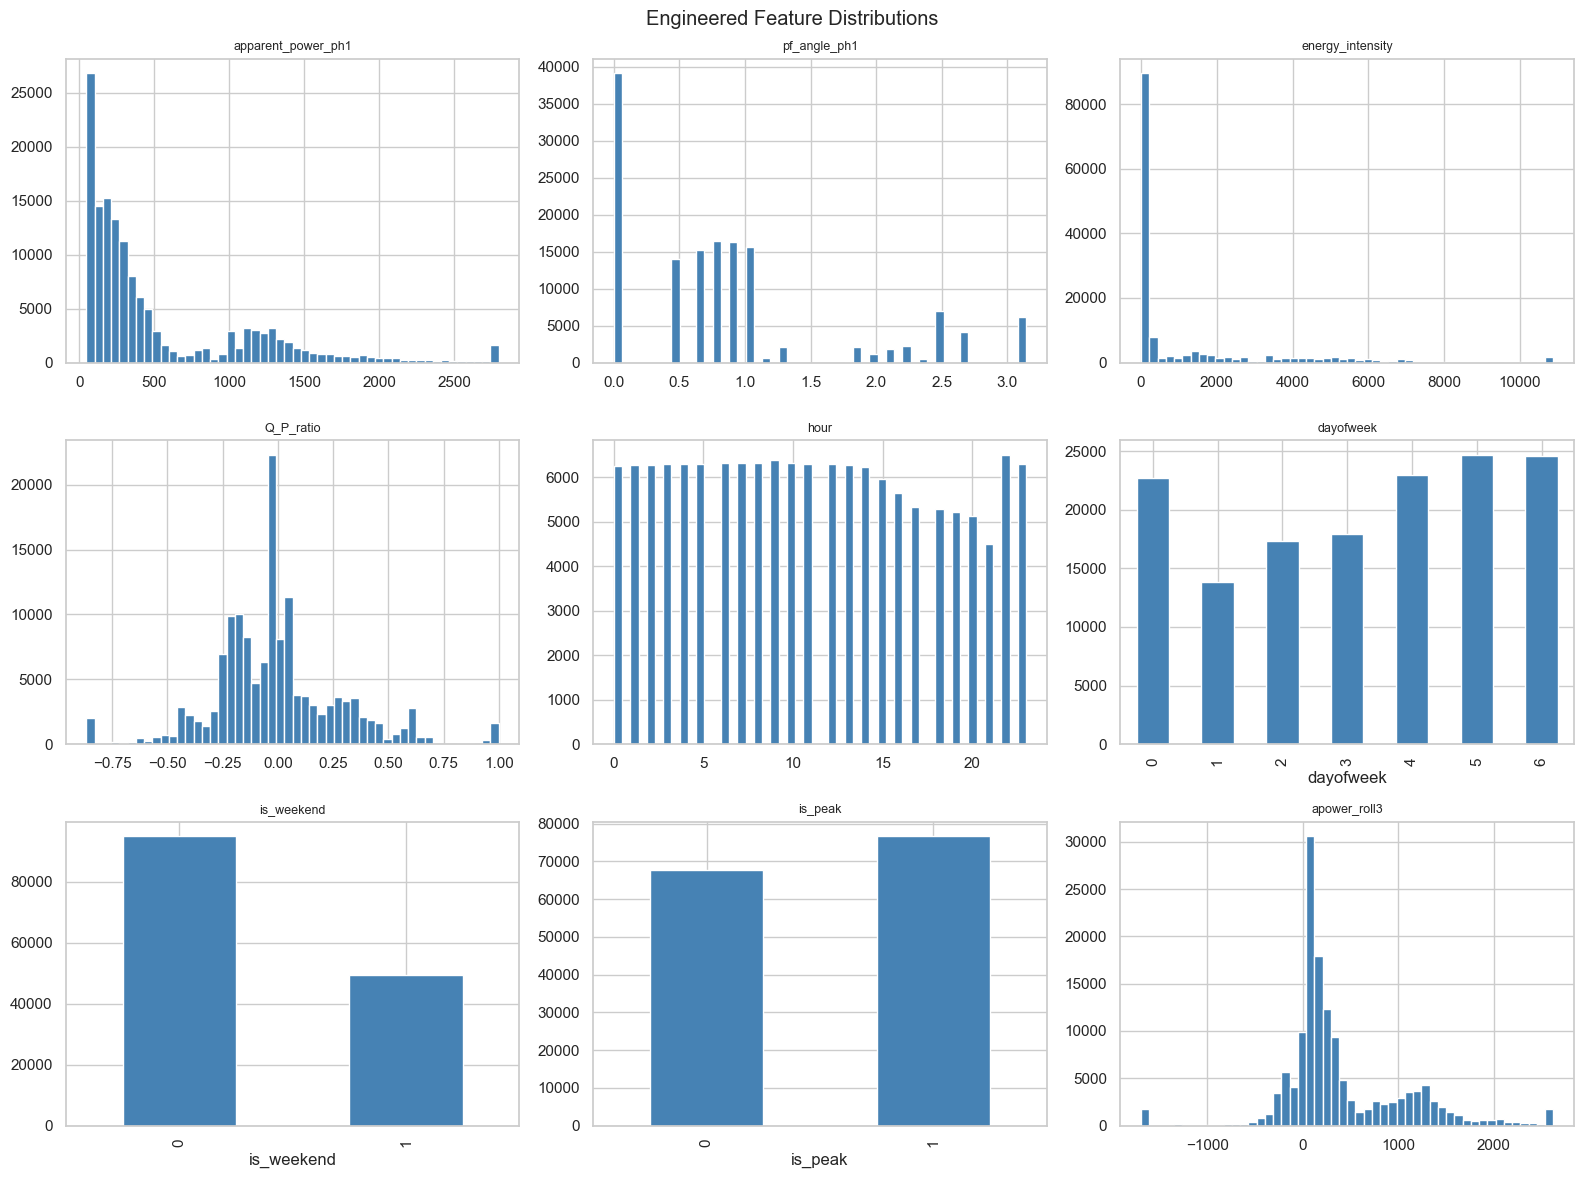

In [70]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flat
for ax, feat in zip(axes, new_feats):
    data = df_fe[feat].dropna()
    if data.nunique() <= 10:
        data.value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    else:
        ax.hist(data.clip(data.quantile(0.01), data.quantile(0.99)), bins=50,
                color='steelblue', edgecolor='white')
    ax.set_title(feat, fontsize=9)
plt.suptitle('Engineered Feature Distributions')
plt.tight_layout()
plt.show()

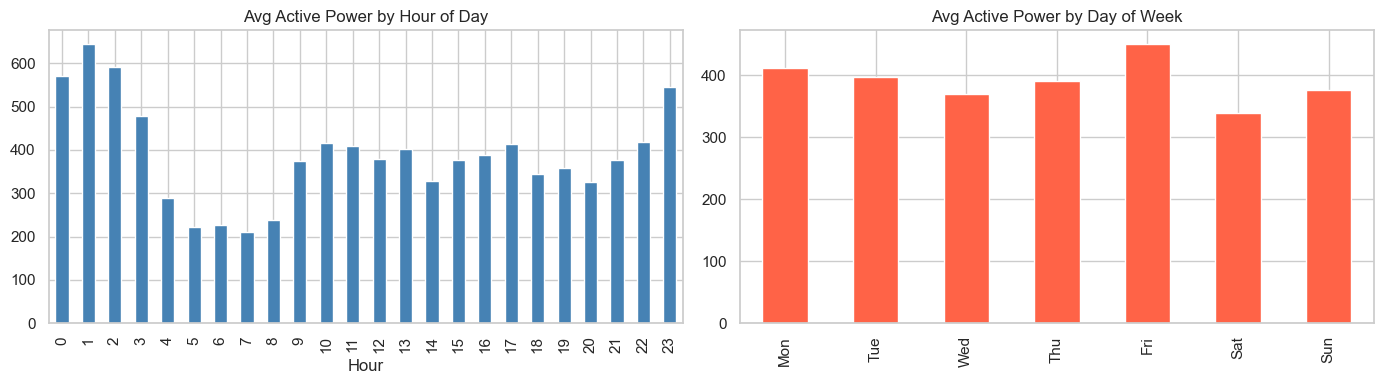

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
hourly = df_fe.groupby('hour')['apower_ph1'].mean()
hourly.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Avg Active Power by Hour of Day')
axes[0].set_xlabel('Hour')

dow_avg = df_fe.groupby('dayofweek')['apower_ph1'].mean()
dow_avg.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_avg.plot(kind='bar', ax=axes[1], color='tomato', edgecolor='white')
axes[1].set_title('Avg Active Power by Day of Week')
plt.tight_layout()
plt.show()

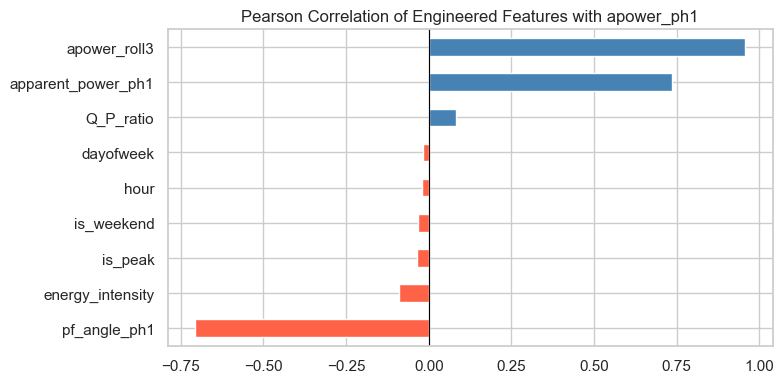

In [72]:
# Correlation of engineered features with apower_ph1
corr_new = df_fe[['apower_ph1'] + new_feats].corr()['apower_ph1'].drop('apower_ph1').sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
corr_new.plot(kind='barh', ax=ax,
              color=['tomato' if v < 0 else 'steelblue' for v in corr_new])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson Correlation of Engineered Features with apower_ph1')
plt.tight_layout()
plt.show()

## 7. Dimensionality Reduction — PCA

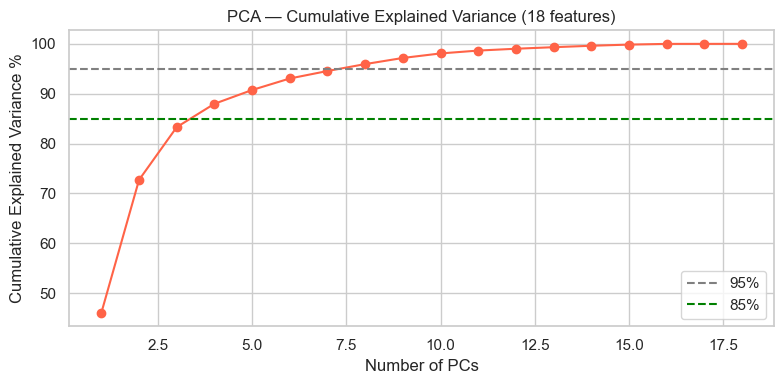

PCs to explain 85%: 4
PCs to explain 95%: 8

  PC  Explained Var %  Cumulative %
 PC1            46.03         46.03
 PC2            26.67         72.70
 PC3            10.59         83.29
 PC4             4.68         87.97
 PC5             2.77         90.74
 PC6             2.31         93.05
 PC7             1.50         94.55
 PC8             1.39         95.94
 PC9             1.23         97.17
PC10             0.91         98.08
PC11             0.57         98.65
PC12             0.37         99.02
PC13             0.31         99.33
PC14             0.29         99.62
PC15             0.23         99.85
PC16             0.14         99.99
PC17             0.00        100.00
PC18             0.00        100.00


In [73]:
# Scale all features (9 original + 9 engineered = 18 total) before PCA
ALL_FEAT_COLS = NUM_COLS + new_feats

X_pca_raw = df_fe[ALL_FEAT_COLS].dropna()

full_scaler_map = {
    'aenergy':            RobustScaler(),
    'aenergy_ph1':        RobustScaler(),
    'renergy':            RobustScaler(),
    'renergy_ph1':        RobustScaler(),
    'apower_ph1':         RobustScaler(),
    'rpower_ph1':         RobustScaler(),
    'current_ph1':        RobustScaler(),
    'pfactor_ph1':        MinMaxScaler(),
    'voltage_ph1':        StandardScaler(),
    'apparent_power_ph1': RobustScaler(),
    'pf_angle_ph1':       MinMaxScaler(),
    'energy_intensity':   RobustScaler(),
    'Q_P_ratio':          RobustScaler(),
    'hour':               MinMaxScaler(),
    'dayofweek':          MinMaxScaler(),
    'is_weekend':         MinMaxScaler(),
    'is_peak':            MinMaxScaler(),
    'apower_roll3':       RobustScaler(),
}

X_pca = X_pca_raw.copy()
for col, scaler in full_scaler_map.items():
    X_pca[[col]] = scaler.fit_transform(X_pca_raw[[col]])

# Full PCA to assess variance
pca_full   = PCA()
pca_full.fit(X_pca)
explained  = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

n_85 = np.argmax(cumulative >= 0.85) + 1
n_95 = np.argmax(cumulative >= 0.95) + 1

# Cumulative explained variance plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(cumulative) + 1), cumulative * 100, marker='o', color='tomato')
ax.axhline(95, linestyle='--', color='gray', label='95%')
ax.axhline(85, linestyle='--', color='green', label='85%')
ax.set_xlabel('Number of PCs')
ax.set_ylabel('Cumulative Explained Variance %')
ax.set_title(f'PCA — Cumulative Explained Variance ({len(ALL_FEAT_COLS)} features)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'PCs to explain 85%: {n_85}')
print(f'PCs to explain 95%: {n_95}')
print()
print(pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(len(explained))],
    'Explained Var %': (explained * 100).round(2),
    'Cumulative %':    (cumulative * 100).round(2)
}).to_string(index=False))

In [74]:
# Retain PCs covering 95% variance
pca = PCA(n_components=n_95)
X_transformed = pca.fit_transform(X_pca)

print(f'Original feature space : {X_pca.shape[1]} features')
print(f'Reduced feature space  : {X_transformed.shape[1]} principal components')
print(f'Variance retained      : {cumulative[n_95 - 1] * 100:.1f}%')
print(f'Samples                : {X_transformed.shape[0]:,}')

# Top 3 contributing features per PC
loading_df = pd.DataFrame(
    pca.components_.T,
    index=ALL_FEAT_COLS,
    columns=[f'PC{i+1}' for i in range(n_95)]
)
print('\nTop contributing features per PC:')
for pc in loading_df.columns:
    top = loading_df[pc].abs().nlargest(3).index.tolist()
    print(f'  {pc}: {top}')

Original feature space : 18 features
Reduced feature space  : 8 principal components
Variance retained      : 95.9%
Samples                : 144,256

Top contributing features per PC:
  PC1: ['aenergy_ph1', 'energy_intensity', 'voltage_ph1']
  PC2: ['apower_ph1', 'aenergy', 'apower_roll3']
  PC3: ['energy_intensity', 'aenergy_ph1', 'Q_P_ratio']
  PC4: ['Q_P_ratio', 'aenergy_ph1', 'rpower_ph1']
  PC5: ['apparent_power_ph1', 'current_ph1', 'apower_ph1']
  PC6: ['aenergy', 'renergy', 'current_ph1']
  PC7: ['renergy', 'is_weekend', 'rpower_ph1']
  PC8: ['is_weekend', 'dayofweek', 'renergy']
